## EDA

In [2]:
import pandas as pd

In [2]:
df=pd.read_csv('scrapreview-ml.csv')
df.head()

,Unnamed: 0,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,0,36643b15-3dfa-41e8-a546-6c8c19dd2cc5,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,cocok untuk belanja dengan diskon yang sangat ...,5,0,NaN,2026-04-20 13:22:11,"Hi kak Tatik Murniati , makasih ya untuk binta...",2026-04-20 14:32:22,NaN
1,1,d3d3648f-56e2-4b6d-a13e-63768fa36549,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,iklannya terlalu meresahkan,1,0,3.72.29,2026-04-20 13:22:05,NaN,NaN,3.72.29
2,2,1433538a-1c84-4635-9b1e-99d4599f6cd7,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mau cod susahnya ampun🤦 bilangnya ini itulah.....,1,0,3.71.29,2026-04-20 13:22:00,NaN,NaN,3.71.29
3,3,f73f8c62-1a76-4adc-ae74-e3e531a94054,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Utk pengguna shopee (terutama seller), OFF-kan...",1,1,3.72.29,2026-04-20 13:21:18,"Hi kak Eri Han, Maaf yaa udah bikin kamu kecew...",2026-04-18 21:38:17,3.72.29
4,4,49aeafcc-81fd-4590-ab6c-3f97d9de74de,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,aplikasi yangg baguss,4,0,3.71.31,2026-04-20 13:21:00,"Hai kak Silvia Irani, waah makasih banyak ya u...",2026-04-20 14:30:16,3.71.31


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10020 entries, 0 to 10019
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Unnamed: 0            10020 non-null  int64 
 1   reviewId              10020 non-null  object
 2   userName              10020 non-null  object
 3   userImage             10020 non-null  object
 4   content               10020 non-null  object
 5   score                 10020 non-null  int64 
 6   thumbsUpCount         10020 non-null  int64 
 7   reviewCreatedVersion  7769 non-null   object
 8   at                    10020 non-null  object
 9   replyContent          8934 non-null   object
 10  repliedAt             8934 non-null   object
 11  appVersion            7769 non-null   object
dtypes: int64(3), object(9)
memory usage: 939.5+ KB


In [4]:
df['content'].isnull().sum()

np.int64(0)

In [5]:
df.duplicated().sum()

np.int64(0)

## Data Cleaning

In [6]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=e06b44674fcb694b3ab875e6694b518d3403ecf0d47e347b2fa88a412654e583
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [7]:
!pip install emoji googletrans

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 3.2 MB/s eta 0:00:00


In [8]:
import re
import string
import nltk
import emoji
from googletrans import Translator
from langdetect import detect

In [9]:
df.drop(columns=['Unnamed: 0','reviewId','userName','userImage','thumbsUpCount','replyContent','repliedAt','appVersion','reviewCreatedVersion'],inplace=True)

In [10]:
df.head()

,content,score,at
0,cocok untuk belanja dengan diskon yang sangat ...,5,2026-04-20 13:22:11
1,iklannya terlalu meresahkan,1,2026-04-20 13:22:05
2,mau cod susahnya ampun🤦 bilangnya ini itulah.....,1,2026-04-20 13:22:00
3,"Utk pengguna shopee (terutama seller), OFF-kan...",1,2026-04-20 13:21:18
4,aplikasi yangg baguss,4,2026-04-20 13:21:00


In [11]:
dataset = pd.read_csv("hf://datasets/theonlydo/indonesia-slang/slang-indo.csv")
# Ubah dataset menjadi dictionary slangwords
slangwords = {}

for index,row in dataset.iterrows():
    slang = row["slang"]
    formal = row["formal"]
    slangwords[slang.lower()] = formal.lower()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [12]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = emoji.demojize(text, delimiters=(" ", " "))
    text = text.replace(":"," ")
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text
def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
  text = text.lower()
  return text
def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        fixed_words.append(slangwords.get(word.lower(), word))

    return ' '.join(fixed_words)
def translateText(text):
    try:
        if detect(text) == 'en':
            text = translator.translate(text, src='en', dest='id').text
    except:
        pass
    return text

In [13]:
data_clean=df.copy()
data_clean['clean_content'] = data_clean['content'].apply(cleaningText)
data_clean['case_content']=data_clean['clean_content'].apply(casefoldingText)
data_clean['slang_content']=data_clean['case_content'].apply(fix_slangwords)
data_clean['final_content']=data_clean['slang_content'].apply(translateText)

In [14]:
data_clean

,content,score,at,clean_content,case_content,slang_content,final_content
0,cocok untuk belanja dengan diskon yang sangat ...,5,2026-04-20 13:22:11,cocok untuk belanja dengan diskon yang sangat ...,cocok untuk belanja dengan diskon yang sangat ...,cocok untuk belanja dengan diskon yang sangat ...,cocok untuk belanja dengan diskon yang sangat ...
1,iklannya terlalu meresahkan,1,2026-04-20 13:22:05,iklannya terlalu meresahkan,iklannya terlalu meresahkan,iklannya terlalu meresahkan,iklannya terlalu meresahkan
2,mau cod susahnya ampun🤦 bilangnya ini itulah.....,1,2026-04-20 13:22:00,mau cod susahnya ampun personfacepalming bilan...,mau cod susahnya ampun personfacepalming bilan...,mau cod susahnya ampun personfacepalming bilan...,mau cod susahnya ampun personfacepalming bilan...
3,"Utk pengguna shopee (terutama seller), OFF-kan...",1,2026-04-20 13:21:18,Utk pengguna shopee terutama seller OFF kan ek...,utk pengguna shopee terutama seller off kan ek...,untuk pengguna shopee terutama seller off kan ...,untuk pengguna shopee terutama seller off kan ...
4,aplikasi yangg baguss,4,2026-04-20 13:21:00,aplikasi yangg baguss,aplikasi yangg baguss,aplikasi yangg bagus,aplikasi yangg bagus
...,...,...,...,...,...,...,...
10015,"sangat puas dengan layanannya, semoga kedepan ...",5,2026-04-09 01:07:37,sangat puas dengan layanannya semoga kedepan m...,sangat puas dengan layanannya semoga kedepan m...,sangat puas dengan layanannya semoga kedepan m...,sangat puas dengan layanannya semoga kedepan m...
10016,Yuhu,1,2026-04-09 01:05:23,Yuhu,yuhu,yuhu,yuhu
10017,"shopee nya sih oke, tapi yg jadi persoalan akh...",5,2026-04-09 01:05:10,shopee nya sih oke tapi yg jadi persoalan akhi...,shopee nya sih oke tapi yg jadi persoalan akhi...,shopee nya sih oke tapi yang jadi persoalan ak...,shopee nya sih oke tapi yang jadi persoalan ak...
10018,oke,5,2026-04-09 01:04:04,oke,oke,oke,oke


In [15]:
data_clean.isna().sum()

,0
content,0
score,0
at,0
clean_content,0
case_content,0
slang_content,0
final_content,0


In [16]:
data_clean.to_csv('data_clean=shopee.csv')

## Labeling (IndoBert)

In [3]:
data_clean=pd.read_csv('/content/data_clean=shopee (1).csv')
data_clean.head()

,Unnamed: 0,content,score,at,clean_content,case_content,slang_content,final_content
0,0,cocok untuk belanja dengan diskon yang sangat ...,5,2026-04-20 13:22:11,cocok untuk belanja dengan diskon yang sangat ...,cocok untuk belanja dengan diskon yang sangat ...,cocok untuk belanja dengan diskon yang sangat ...,cocok untuk belanja dengan diskon yang sangat ...
1,1,iklannya terlalu meresahkan,1,2026-04-20 13:22:05,iklannya terlalu meresahkan,iklannya terlalu meresahkan,iklannya terlalu meresahkan,iklannya terlalu meresahkan
2,2,mau cod susahnya ampun🤦 bilangnya ini itulah.....,1,2026-04-20 13:22:00,mau cod susahnya ampun personfacepalming bilan...,mau cod susahnya ampun personfacepalming bilan...,mau cod susahnya ampun personfacepalming bilan...,mau cod susahnya ampun personfacepalming bilan...
3,3,"Utk pengguna shopee (terutama seller), OFF-kan...",1,2026-04-20 13:21:18,Utk pengguna shopee terutama seller OFF kan ek...,utk pengguna shopee terutama seller off kan ek...,untuk pengguna shopee terutama seller off kan ...,untuk pengguna shopee terutama seller off kan ...
4,4,aplikasi yangg baguss,4,2026-04-20 13:21:00,aplikasi yangg baguss,aplikasi yangg baguss,aplikasi yangg bagus,aplikasi yangg bagus


In [6]:
data_clean[data_clean.isna().any(axis=1)]
data_clean.drop(columns=['Unnamed: 0'],inplace=True)
data_clean.dropna(inplace=True)

In [7]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm

In [8]:
pretrained_name = "w11wo/indonesian-roberta-base-sentiment-classifier"
tokenize=AutoTokenizer.from_pretrained(pretrained_name)
model=AutoModelForSequenceClassification.from_pretrained(pretrained_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [9]:
print(model.config.id2label)

{0: 'positive', 1: 'neutral', 2: 'negative'}


In [10]:
label_map = {0: 'positive', 1: 'neutral', 2: 'negative'}

def predict_batch(texts, batch_size=32):
    predictions = []
    model.eval()

    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i:i+batch_size]

        inputs = tokenize(
            batch_texts,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=128
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs)

        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        predictions.extend([label_map[p] for p in preds])

    return predictions

In [11]:

print(torch.cuda.is_available())

True


In [12]:
data_labeling=data_clean.copy()
data_labeling['Label']=predict_batch(data_labeling['final_content'].tolist())

100%|██████████| 314/314 [00:36<00:00,  8.62it/s]


In [13]:
data_labeling

,content,score,at,clean_content,case_content,slang_content,final_content,Label
0,cocok untuk belanja dengan diskon yang sangat ...,5,2026-04-20 13:22:11,cocok untuk belanja dengan diskon yang sangat ...,cocok untuk belanja dengan diskon yang sangat ...,cocok untuk belanja dengan diskon yang sangat ...,cocok untuk belanja dengan diskon yang sangat ...,positive
1,iklannya terlalu meresahkan,1,2026-04-20 13:22:05,iklannya terlalu meresahkan,iklannya terlalu meresahkan,iklannya terlalu meresahkan,iklannya terlalu meresahkan,negative
2,mau cod susahnya ampun🤦 bilangnya ini itulah.....,1,2026-04-20 13:22:00,mau cod susahnya ampun personfacepalming bilan...,mau cod susahnya ampun personfacepalming bilan...,mau cod susahnya ampun personfacepalming bilan...,mau cod susahnya ampun personfacepalming bilan...,negative
3,"Utk pengguna shopee (terutama seller), OFF-kan...",1,2026-04-20 13:21:18,Utk pengguna shopee terutama seller OFF kan ek...,utk pengguna shopee terutama seller off kan ek...,untuk pengguna shopee terutama seller off kan ...,untuk pengguna shopee terutama seller off kan ...,negative
4,aplikasi yangg baguss,4,2026-04-20 13:21:00,aplikasi yangg baguss,aplikasi yangg baguss,aplikasi yangg bagus,aplikasi yangg bagus,positive
...,...,...,...,...,...,...,...,...
10015,"sangat puas dengan layanannya, semoga kedepan ...",5,2026-04-09 01:07:37,sangat puas dengan layanannya semoga kedepan m...,sangat puas dengan layanannya semoga kedepan m...,sangat puas dengan layanannya semoga kedepan m...,sangat puas dengan layanannya semoga kedepan m...,positive
10016,Yuhu,1,2026-04-09 01:05:23,Yuhu,yuhu,yuhu,yuhu,negative
10017,"shopee nya sih oke, tapi yg jadi persoalan akh...",5,2026-04-09 01:05:10,shopee nya sih oke tapi yg jadi persoalan akhi...,shopee nya sih oke tapi yg jadi persoalan akhi...,shopee nya sih oke tapi yang jadi persoalan ak...,shopee nya sih oke tapi yang jadi persoalan ak...,positive
10018,oke,5,2026-04-09 01:04:04,oke,oke,oke,oke,negative


In [14]:
data_labeling['Label'].value_counts()

,count
Label,
positive,5417
negative,3924
neutral,677


([<matplotlib.patches.Wedge at 0x79478fc3c980>,
 [Text(-0.12595111360608405, 1.0927654446318238, 'positive'),
  Text(-0.13348594232427813, -1.0918706439875558, 'negative'),
  Text(1.0694051784675633, -0.257628733387329, 'neutral')])

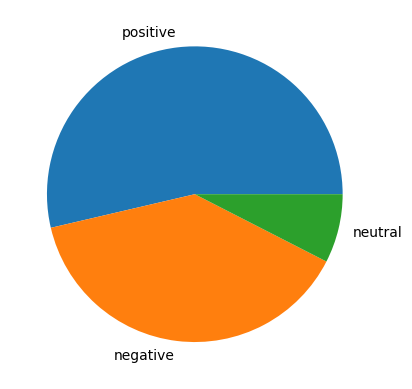

In [ ]:
from matplotlib import pyplot as plt
value_counts = data_labeling['Label'].value_counts()
labels = value_counts.index
fig, ax = plt.subplots()
ax.pie(value_counts, labels=labels,)

In [15]:
data_labeling.to_csv('data_labeling=shopee.csv')

In [16]:
data_labeling=pd.read_csv('data_labeling=shopee.csv')
data_labeling

,Unnamed: 0,content,score,at,clean_content,case_content,slang_content,final_content,Label
0,0,cocok untuk belanja dengan diskon yang sangat ...,5,2026-04-20 13:22:11,cocok untuk belanja dengan diskon yang sangat ...,cocok untuk belanja dengan diskon yang sangat ...,cocok untuk belanja dengan diskon yang sangat ...,cocok untuk belanja dengan diskon yang sangat ...,positive
1,1,iklannya terlalu meresahkan,1,2026-04-20 13:22:05,iklannya terlalu meresahkan,iklannya terlalu meresahkan,iklannya terlalu meresahkan,iklannya terlalu meresahkan,negative
2,2,mau cod susahnya ampun🤦 bilangnya ini itulah.....,1,2026-04-20 13:22:00,mau cod susahnya ampun personfacepalming bilan...,mau cod susahnya ampun personfacepalming bilan...,mau cod susahnya ampun personfacepalming bilan...,mau cod susahnya ampun personfacepalming bilan...,negative
3,3,"Utk pengguna shopee (terutama seller), OFF-kan...",1,2026-04-20 13:21:18,Utk pengguna shopee terutama seller OFF kan ek...,utk pengguna shopee terutama seller off kan ek...,untuk pengguna shopee terutama seller off kan ...,untuk pengguna shopee terutama seller off kan ...,negative
4,4,aplikasi yangg baguss,4,2026-04-20 13:21:00,aplikasi yangg baguss,aplikasi yangg baguss,aplikasi yangg bagus,aplikasi yangg bagus,positive
...,...,...,...,...,...,...,...,...,...
10013,10015,"sangat puas dengan layanannya, semoga kedepan ...",5,2026-04-09 01:07:37,sangat puas dengan layanannya semoga kedepan m...,sangat puas dengan layanannya semoga kedepan m...,sangat puas dengan layanannya semoga kedepan m...,sangat puas dengan layanannya semoga kedepan m...,positive
10014,10016,Yuhu,1,2026-04-09 01:05:23,Yuhu,yuhu,yuhu,yuhu,negative
10015,10017,"shopee nya sih oke, tapi yg jadi persoalan akh...",5,2026-04-09 01:05:10,shopee nya sih oke tapi yg jadi persoalan akhi...,shopee nya sih oke tapi yg jadi persoalan akhi...,shopee nya sih oke tapi yang jadi persoalan ak...,shopee nya sih oke tapi yang jadi persoalan ak...,positive
10016,10018,oke,5,2026-04-09 01:04:04,oke,oke,oke,oke,negative


## TF-IDF + Naive Bayes + Pembagian Data: 80/20

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

In [18]:
X=data_labeling['final_content']
y=data_labeling['Label']

tfidf=TfidfVectorizer()
X_tfidf=tfidf.fit_transform(X)

x_train,x_test,y_train,y_test=train_test_split(X_tfidf,y, test_size=0.2, random_state=42,stratify=y)

In [19]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    x_train.toarray(),
    y_train
)

In [23]:
print(X_train_smote.shape)
print(y_train.value_counts())
print(y_train_smote.value_counts())


(12999, 8425)
Label
positive    4333
negative    3139
neutral      542
Name: count, dtype: int64
Label
positive    4333
negative    4333
neutral     4333
Name: count, dtype: int64


In [24]:
modelnb = MultinomialNB()
modelnb.fit(X_train_smote, y_train_smote)

pred=modelnb.predict(x_test)
print(classification_report(y_test,pred))
acc1=accuracy_score(y_test,pred)
print(f"Accuracy: {acc1 * 100:.2f}%")

              precision    recall  f1-score   support

    negative       0.86      0.87      0.86       785
     neutral       0.41      0.51      0.46       135
    positive       0.91      0.87      0.89      1084

    accuracy                           0.85      2004
   macro avg       0.73      0.75      0.74      2004
weighted avg       0.85      0.85      0.85      2004

Accuracy: 84.58%


In [25]:
pred_train=modelnb.score(x_train,y_train)
print(f"Training Accuracy: {pred_train * 100:.2f}%")

Training Accuracy: 90.59%


## Ensembel Learning + TF IDF + Pemabagian Data:80/20

In [26]:
X=data_labeling['final_content']
y=data_labeling['Label']

tfidf=TfidfVectorizer()
X_tfidf=tfidf.fit_transform(X)

x_train,x_test,y_train,y_test=train_test_split(X_tfidf,y, test_size=0.2, random_state=42)


In [27]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    x_train.toarray(),
    y_train
)

### Random Forest

In [28]:
from sklearn.ensemble import RandomForestClassifier
modelrf=RandomForestClassifier()
modelrf.fit(X_train_smote,y_train_smote)

pred3=modelrf.predict(x_test)
print(classification_report(y_test,pred3))
acc2=accuracy_score(y_test,pred3)
print(f"Accuracy: {acc2 * 100:.2f}%")

              precision    recall  f1-score   support

    negative       0.85      0.88      0.87       812
     neutral       0.38      0.56      0.45       120
    positive       0.94      0.86      0.90      1072

    accuracy                           0.85      2004
   macro avg       0.72      0.77      0.74      2004
weighted avg       0.87      0.85      0.86      2004

Accuracy: 85.18%


### XGBoost

In [32]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
modelXGB=XGBClassifier()
modelXGB.fit(x_train,y_train_encoded)

pred4=modelXGB.predict(x_test)
print(classification_report(y_test_encoded,pred4))

              precision    recall  f1-score   support

           0       0.84      0.94      0.89       812
           1       0.67      0.27      0.38       120
           2       0.93      0.91      0.92      1072

    accuracy                           0.88      2004
   macro avg       0.81      0.70      0.73      2004
weighted avg       0.88      0.88      0.87      2004



In [33]:
acc3=accuracy_score(y_test_encoded,pred4)
print(f"Accuracy: {acc3 * 100:.2f}%")
print(modelXGB.score(x_train,y_train_encoded))

Accuracy: 88.27%
0.9495882206139257


## Word2Vec + Naive Bayes + Pembagian Data:80/20

In [34]:
!pip install Gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 34.4 MB/s eta 0:00:00


In [35]:
from gensim.models import Word2Vec
import numpy as np

In [36]:
dataset2=data_labeling.copy()

X=dataset2['final_content']
y=dataset2['Label']

X = X.apply(lambda x: x.split() if isinstance(x, str) else [])
x_train,x_test,y_train,y_test=train_test_split(X,y, test_size=0.2, random_state=42)

Word2Vec_model=Word2Vec(sentences=x_train, vector_size=100, window=5, min_count=1, workers=4)

In [37]:
Word2Vec_model.wv.most_similar('lama')

[('sekarang', 0.9990876913070679),
 ('datang', 0.9973609447479248),
 ('hari', 0.9973368644714355),
 ('sudah', 0.9970958828926086),
 ('kali', 0.9968523979187012),
 ('minggu', 0.9966082572937012),
 ('menunggu', 0.9963696002960205),
 ('padahal', 0.9963534474372864),
 ('pesan', 0.9962424635887146),
 ('belum', 0.9961768388748169)]

`Mentransformasi Vektor kalimat agar selaras untuk melakukan traning pada model`

In [38]:
words = set(Word2Vec_model.wv.index_to_key)
vector_size = Word2Vec_model.wv.vector_size

def vectorize_sentence(sentence):
    # Filter out words not in the model's vocabulary
    valid_words = [word for word in sentence if word in words]
    if not valid_words:
        # Return a zero vector if no valid words are found in the sentence
        return np.zeros(vector_size)

    # Get vectors for valid words and average them
    word_vectors = np.array([Word2Vec_model.wv[word] for word in valid_words])
    return np.mean(word_vectors, axis=0)

# Apply the vectorization function to x_train and x_test
X_train_vect = np.array([vectorize_sentence(ls) for ls in x_train])
X_test_vect = np.array([vectorize_sentence(ls) for ls in x_test])

In [39]:
from sklearn.naive_bayes import GaussianNB

modelnb2 = GaussianNB()
modelnb2.fit(X_train_vect, y_train)

GaussianNB()

In [40]:
pred2=modelnb2.predict(X_test_vect)
print(classification_report(y_test,pred2))
acc4=accuracy_score(y_test,pred2)
print(f"Accuracy: {acc4 * 100:.2f}%")

              precision    recall  f1-score   support

    negative       0.69      0.74      0.72       812
     neutral       0.13      0.33      0.19       120
    positive       0.90      0.69      0.78      1072

    accuracy                           0.69      2004
   macro avg       0.57      0.59      0.56      2004
weighted avg       0.77      0.69      0.72      2004

Accuracy: 69.06%


In [41]:
modelnb2.score(X_train_vect,y_train)

0.7031444971300225

## TF-IDF + GRU + Pembagian Data:80/20

In [62]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

dataset2=pd.read_csv('data_labeling=shopee.csv')
dataset2

,Unnamed: 0,content,score,at,clean_content,case_content,slang_content,final_content,Label
0,0,cocok untuk belanja dengan diskon yang sangat ...,5,2026-04-20 13:22:11,cocok untuk belanja dengan diskon yang sangat ...,cocok untuk belanja dengan diskon yang sangat ...,cocok untuk belanja dengan diskon yang sangat ...,cocok untuk belanja dengan diskon yang sangat ...,positive
1,1,iklannya terlalu meresahkan,1,2026-04-20 13:22:05,iklannya terlalu meresahkan,iklannya terlalu meresahkan,iklannya terlalu meresahkan,iklannya terlalu meresahkan,negative
2,2,mau cod susahnya ampun🤦 bilangnya ini itulah.....,1,2026-04-20 13:22:00,mau cod susahnya ampun personfacepalming bilan...,mau cod susahnya ampun personfacepalming bilan...,mau cod susahnya ampun personfacepalming bilan...,mau cod susahnya ampun personfacepalming bilan...,negative
3,3,"Utk pengguna shopee (terutama seller), OFF-kan...",1,2026-04-20 13:21:18,Utk pengguna shopee terutama seller OFF kan ek...,utk pengguna shopee terutama seller off kan ek...,untuk pengguna shopee terutama seller off kan ...,untuk pengguna shopee terutama seller off kan ...,negative
4,4,aplikasi yangg baguss,4,2026-04-20 13:21:00,aplikasi yangg baguss,aplikasi yangg baguss,aplikasi yangg bagus,aplikasi yangg bagus,positive
...,...,...,...,...,...,...,...,...,...
10013,10015,"sangat puas dengan layanannya, semoga kedepan ...",5,2026-04-09 01:07:37,sangat puas dengan layanannya semoga kedepan m...,sangat puas dengan layanannya semoga kedepan m...,sangat puas dengan layanannya semoga kedepan m...,sangat puas dengan layanannya semoga kedepan m...,positive
10014,10016,Yuhu,1,2026-04-09 01:05:23,Yuhu,yuhu,yuhu,yuhu,negative
10015,10017,"shopee nya sih oke, tapi yg jadi persoalan akh...",5,2026-04-09 01:05:10,shopee nya sih oke tapi yg jadi persoalan akhi...,shopee nya sih oke tapi yg jadi persoalan akhi...,shopee nya sih oke tapi yang jadi persoalan ak...,shopee nya sih oke tapi yang jadi persoalan ak...,positive
10016,10018,oke,5,2026-04-09 01:04:04,oke,oke,oke,oke,negative


In [43]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, GRU, Embedding
from tensorflow.keras.optimizers import RMSprop, Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [44]:
dataset2=dataset2.copy()

X=dataset2['final_content'].values.tolist()
y=dataset2['Label'].values.tolist()

X = [x.split() if isinstance(x, str) else [] for x in X]
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.2, random_state=42)
Word2Vec_model=Word2Vec(sentences=X, vector_size=100, window=5, min_count=1, workers=4)

In [45]:
embedding_dim = 100
max_words = 5000
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X)

In [46]:
x_train_tokens = tokenizer.texts_to_sequences(X_train)
x_test_tokens = tokenizer.texts_to_sequences(X_test)
x_train_pad=pad_sequences(x_train_tokens,maxlen=100,truncating='post',padding='post')
x_test_pad=pad_sequences(x_test_tokens,maxlen=100,truncating='post',padding='post')

embedding_dim = 100
max_words = 5000

In [47]:
word_index = tokenizer.word_index
embedding_matrix = np.zeros((max_words, embedding_dim))

for word, i in word_index.items():
    if i < max_words and word in Word2Vec_model.wv:
        embedding_matrix[i] = Word2Vec_model.wv[word]


In [48]:
max_len=100

In [51]:
model = Sequential()

model.add(Embedding(
    input_dim=max_words,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=max_len,
    trainable=False
))

model.add(GRU(128))

model.add(Dense(3, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [52]:
for i,j in enumerate(y_train):
  if j == 'positive':
    y_train[i] = 0
  elif j == 'neutral':
    y_train[i] = 1
  elif j == 'negative':
    y_train[i] = 2
y_train = np.array(y_train)
y_train = y_train.astype(np.int32)

In [53]:
history = model.fit(
    x_train_pad,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5420 - loss: 0.8979 - val_accuracy: 0.5424 - val_loss: 0.8788
Epoch 2/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5422 - loss: 0.8886 - val_accuracy: 0.5424 - val_loss: 0.8780
Epoch 3/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6675 - loss: 0.7703 - val_accuracy: 0.7805 - val_loss: 0.6231
Epoch 4/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7761 - loss: 0.5912 - val_accuracy: 0.8254 - val_loss: 0.5033
Epoch 5/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7949 - loss: 0.5229 - val_accuracy: 0.8117 - val_loss: 0.4918
Epoch 6/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7945 - loss: 0.5056 - val_accuracy: 0.8167 - val_loss: 0.4715
Epoch 7/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8039 - loss: 0.4893 - val_accuracy: 0.8379 - val_loss: 0.4532
Epoch 8/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8100 - loss: 0.4869 - val_accuracy:

In [54]:
y_pred_prob = model.predict(x_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [55]:
label_mapping = {'positive': 0, 'neutral': 1, 'negative': 2}
y_test_numeric = [label_mapping[label] for label in y_test]

class_labels = ['positive', 'neutral', 'negative']
classification_rep = classification_report(y_test_numeric, y_pred, target_names=class_labels)
print(classification_rep)

              precision    recall  f1-score   support

    positive       0.92      0.87      0.89      1072
     neutral       0.38      0.30      0.34       120
    negative       0.81      0.89      0.85       812

    accuracy                           0.84      2004
   macro avg       0.70      0.69      0.69      2004
weighted avg       0.84      0.84      0.84      2004



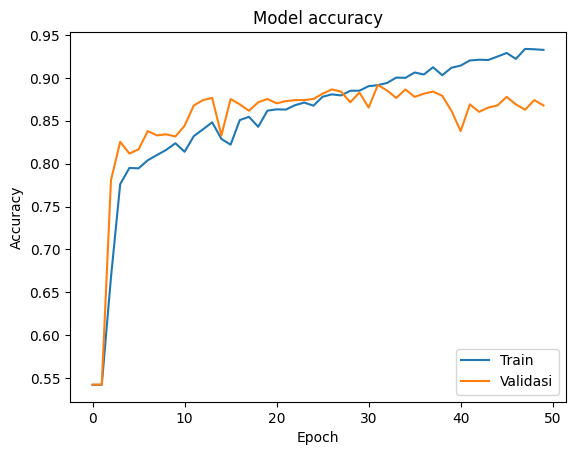

In [58]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validasi'], loc='lower right')
plt.show()

In [60]:
acc5=accuracy_score(y_test_numeric, y_pred)

In [ ]:
print

## Accuray Model

In [63]:
hasil_akurasi = pd.DataFrame({
    'Model': [
        'TF-IDF + Naive Bayes + SMOTE Oversampling',
        'TF-IDF + Random Forest + SMOTE Oversampling',
        'TF-IDF + XGBoost',
        'Word2Vec + Naive Bayes',
        'Word2Vec + GRU'
    ],
    'Accuracy': [acc1, acc2, acc3, acc4, acc5]
})

print(hasil_akurasi)

                                         Model  Accuracy
0    TF-IDF + Naive Bayes + SMOTE Oversampling  0.845808
1  TF-IDF + Random Forest + SMOTE Oversampling  0.851796
2                             TF-IDF + XGBoost  0.882735
3                       Word2Vec + Naive Bayes  0.690619
4                               Word2Vec + GRU  0.844810


## Kesimpulan

## Model Accuracy Comparison

| No | Model                                       | Data Split | Accuracy (%) |
| -- | ------------------------------------------- | :--------: | -----------: |
| 1  | TF-IDF + Naive Bayes + SMOTE Oversampling   |    80/20   |       84.58% |
| 2  | TF-IDF + Random Forest + SMOTE Oversampling |    80/20   |       85.18% |
| 3  | TF-IDF + XGBoost                            |    80/20   |   **88.27%** |
| 4  | Word2Vec + Naive Bayes                      |    80/20   |       69.06% |
| 5  | Word2Vec + GRU                              |    80/20   |       84.48% |



